In [1]:
import json
import numpy as np
import torch
import os


def load_diff_mean_data(path):
    data = {}
    with open(path, "r") as f:
        for line in f:
            item = json.loads(line)
            model = item["model"]
            benchmark = item["benchmark"]
            column = item["column"]
            id = f"{benchmark}_{column}_{model}"
            data[id] = np.array(item["diffmean"])
    return data

def load_linear_model_data(path):
    pt_files = [f for f in os.listdir(path) if f.endswith(".pt")]
    data = {}
    for pt_file in pt_files:
        temp = torch.load(os.path.join(path, pt_file))
        model = temp['model']
        benchmark = temp['benchmark']
        column = temp['column']
        id = f"{benchmark}_{column}_{model}"
        
        data[id] = temp['W']
        
    return data



In [4]:
hinge_path = "pca_64/synthetic_last_pca/hinge"
logistic_path = "pca_64/synthetic_last_pca/logistic"
diff_mean_path = "../diffmean_per_layer_synthetic_pca_64.jsonl"


diff_mean = load_diff_mean_data(diff_mean_path)
hinge_data = load_linear_model_data(hinge_path)
logistic_data = load_linear_model_data(logistic_path)

cosines = {}

for key, diffmean_vector in diff_mean.items():
    if key not in hinge_data or key not in logistic_data:
        continue
    hinge_w = hinge_data[key].numpy()
    logistic_w = logistic_data[key].numpy()
    
    diffmean_norm = diffmean_vector / np.linalg.norm(diffmean_vector, axis=1, keepdims=True)
    
    hinge_w_norm = hinge_w / np.linalg.norm(hinge_w, axis=1, keepdims=True)
    logistic_w_norm = logistic_w / np.linalg.norm(logistic_w, axis=1, keepdims=True)
    
    cosine_hing_diffmean = np.sum(hinge_w_norm * diffmean_norm, axis=1)
    cosine_logi_diffmean = np.sum(logistic_w_norm * diffmean_norm, axis=1)
    cosine_hing_logi = np.sum(hinge_w_norm * logistic_w_norm, axis=1)

    cosines[key] = {
        "cosine_hinge_diffmean": cosine_hing_diffmean.tolist(),
        "cosine_logistic_diffmean": cosine_logi_diffmean.tolist(),
        "cosine_hinge_logistic": cosine_hing_logi.tolist()
    }


with open("within_dataset_cosines_synthetic_pca_64.json", "w") as f:
    json.dump(cosines, f)


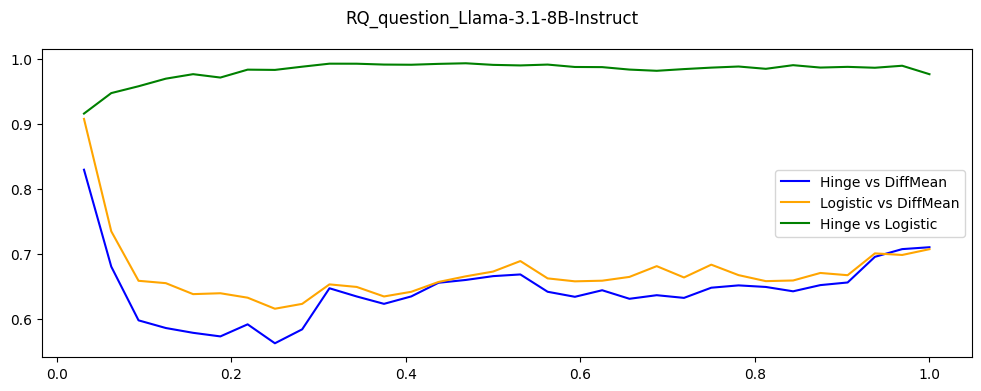

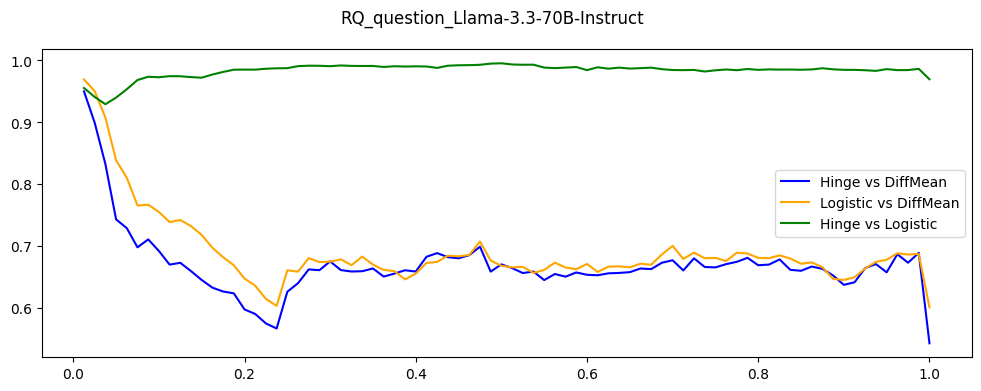

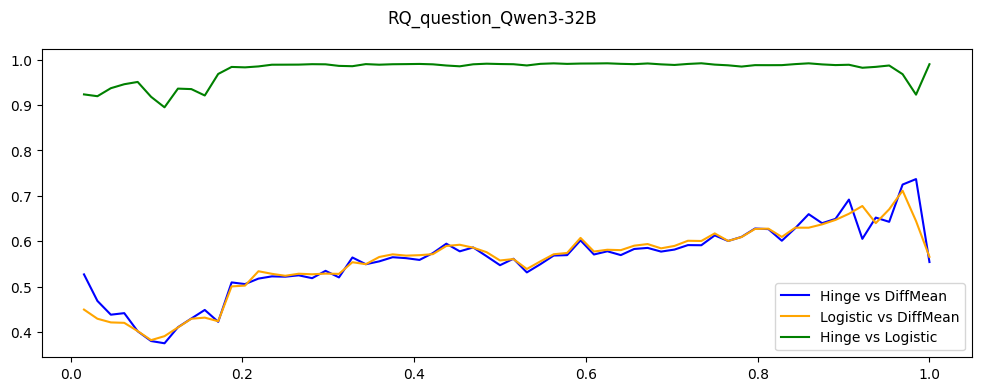

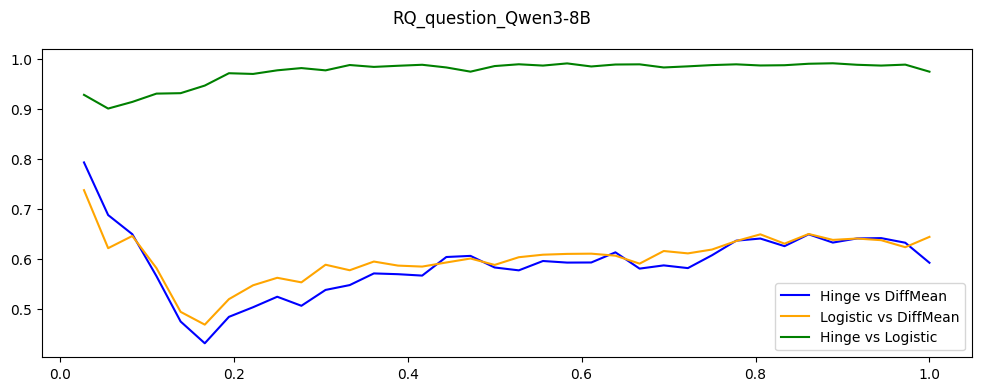

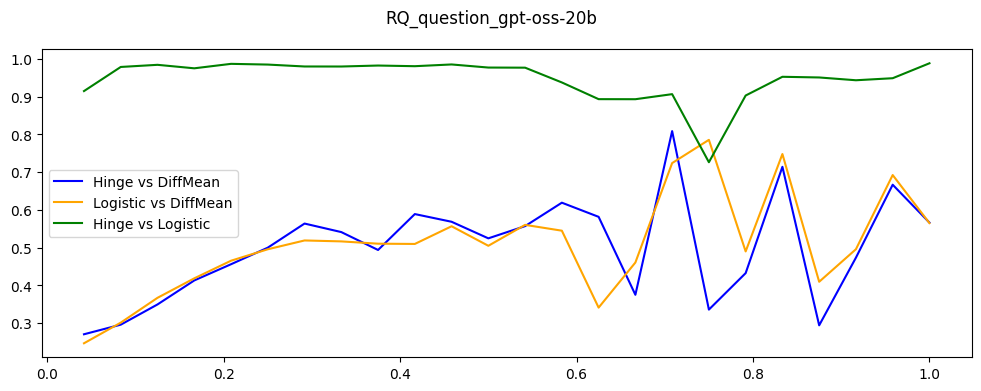

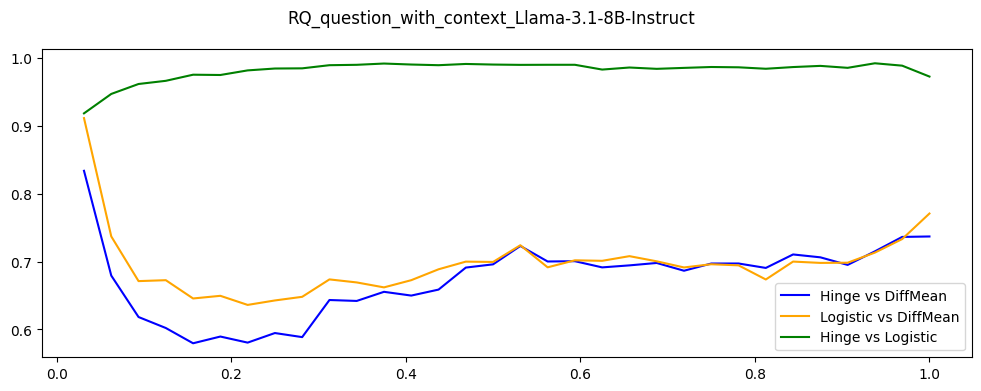

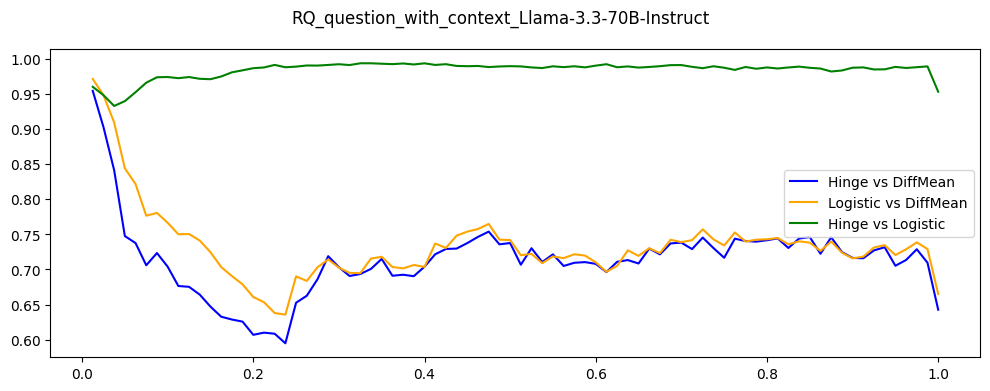

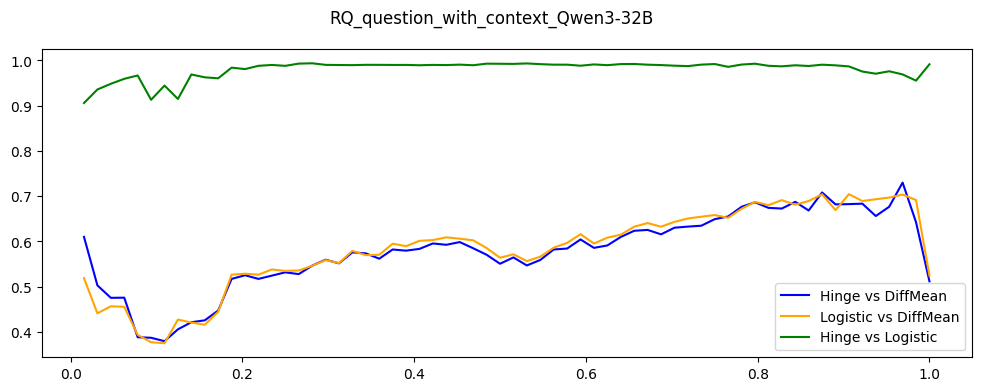

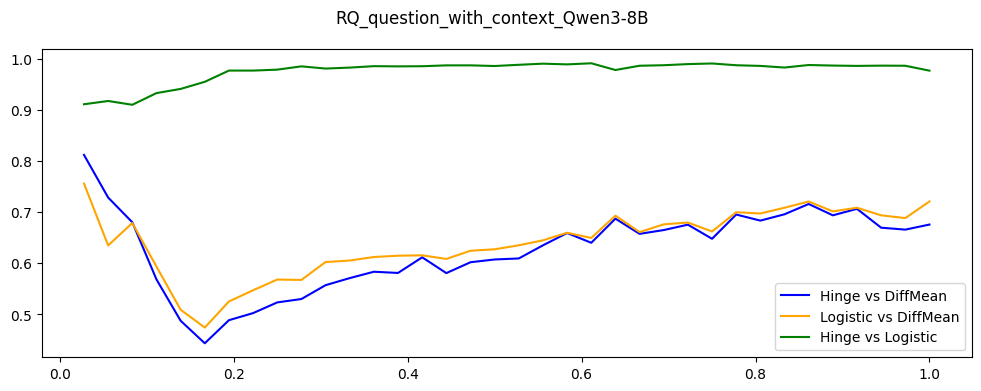

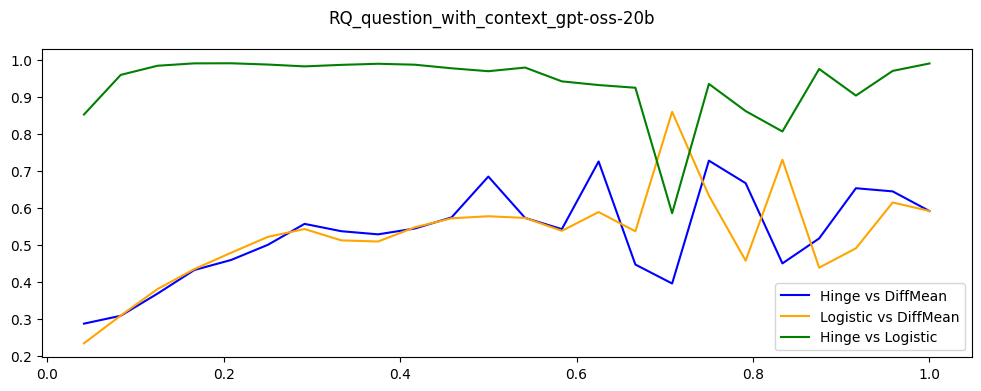

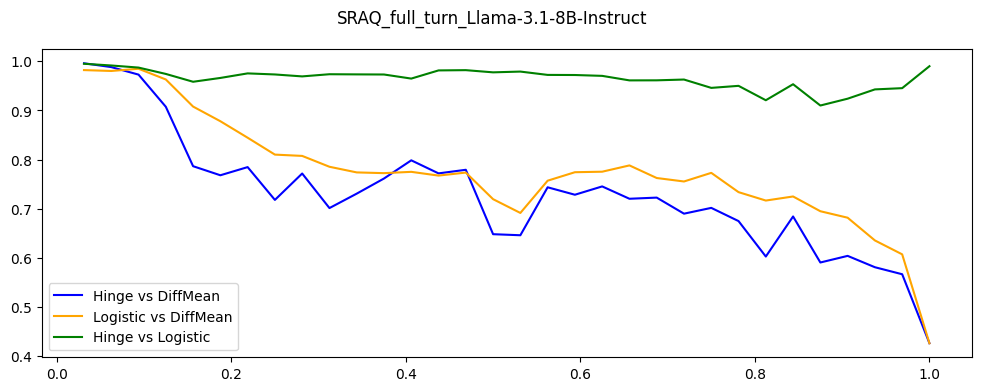

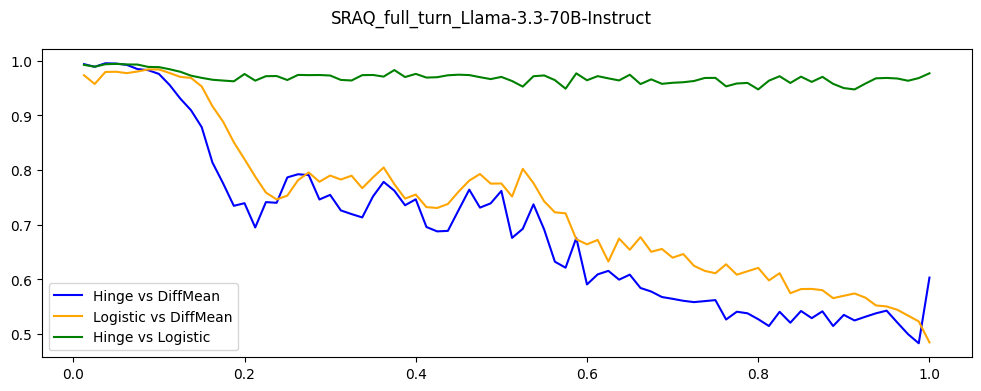

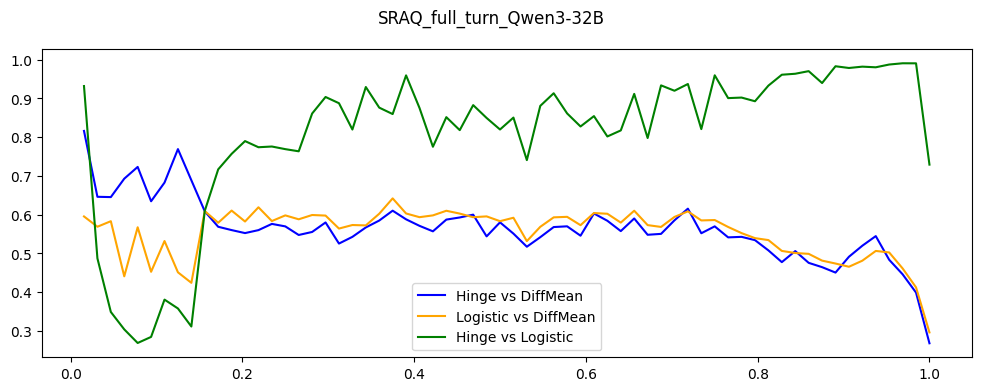

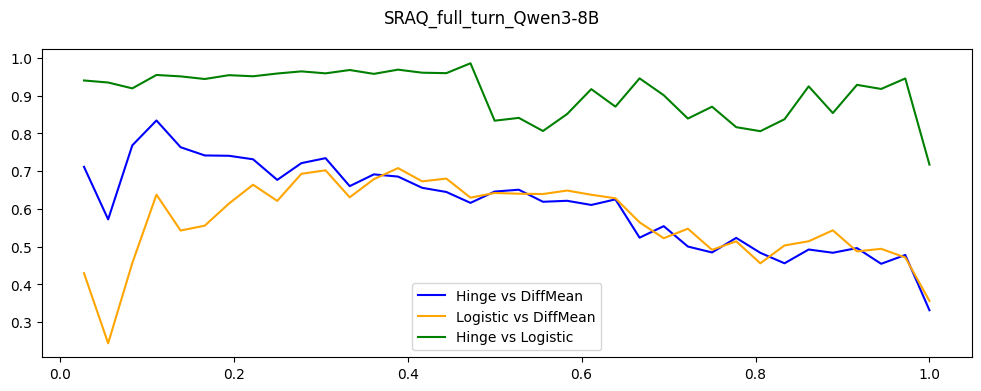

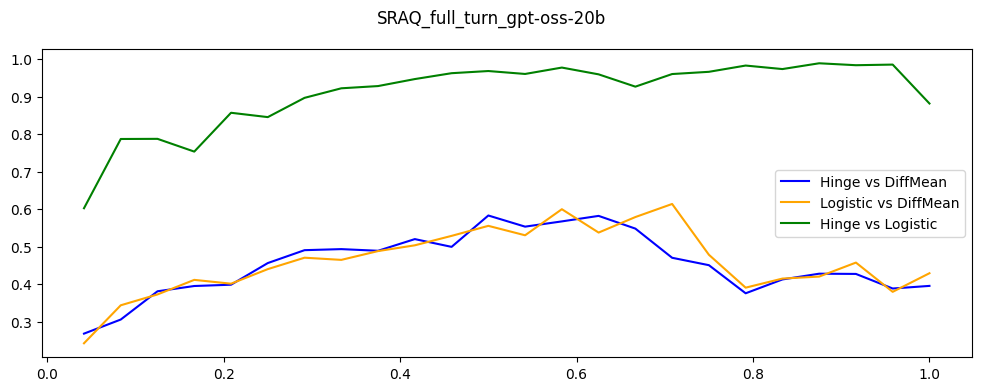

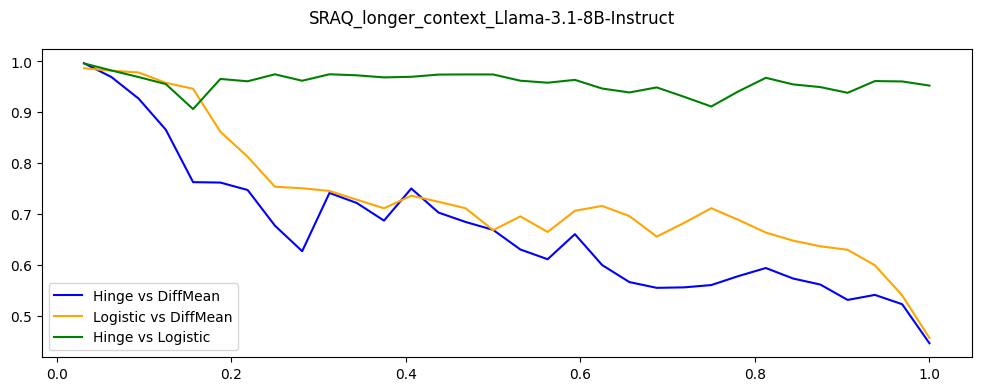

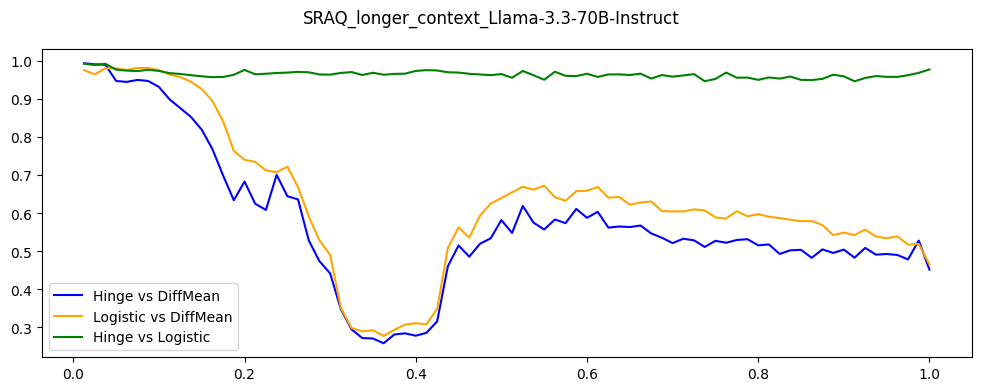

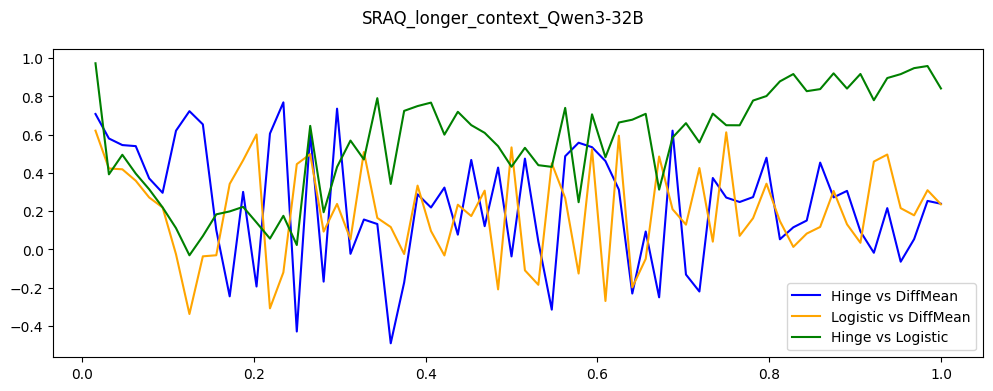

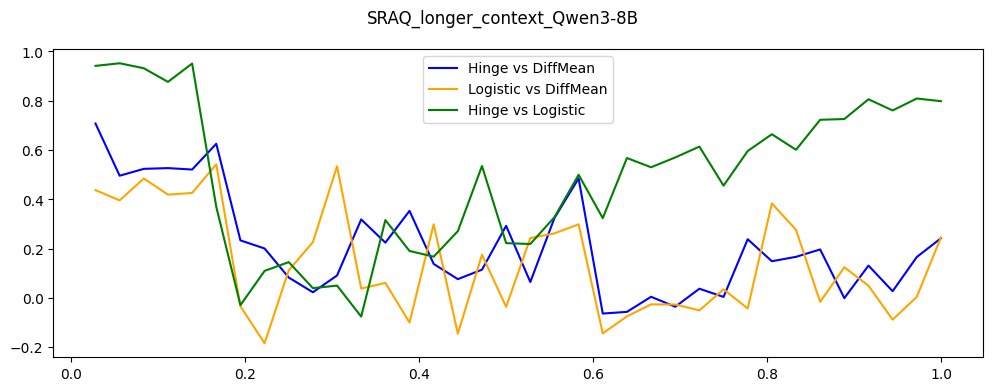

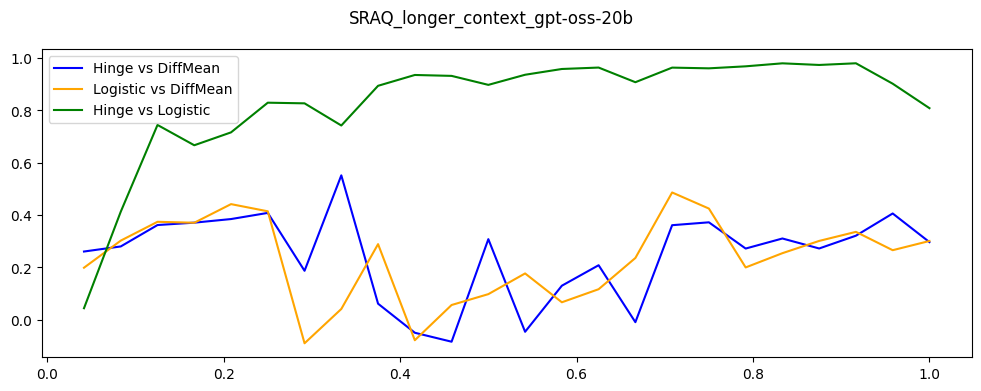

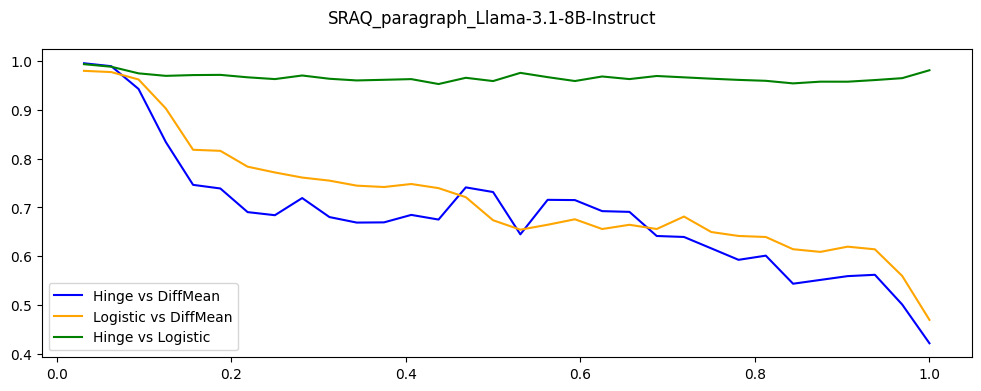

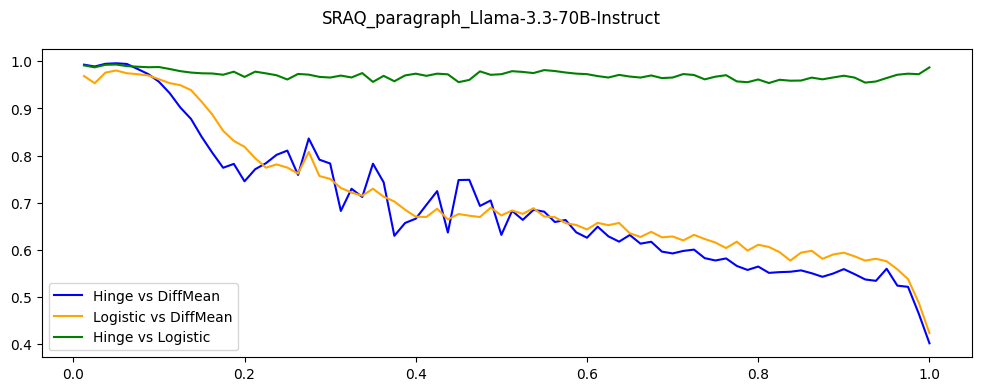

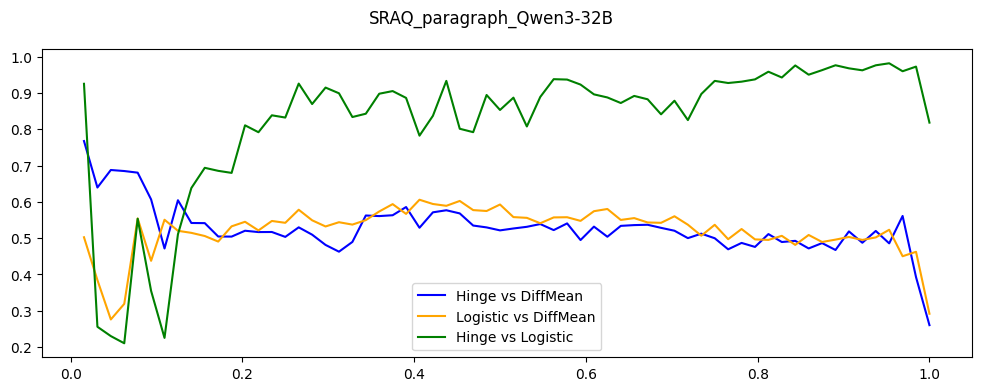

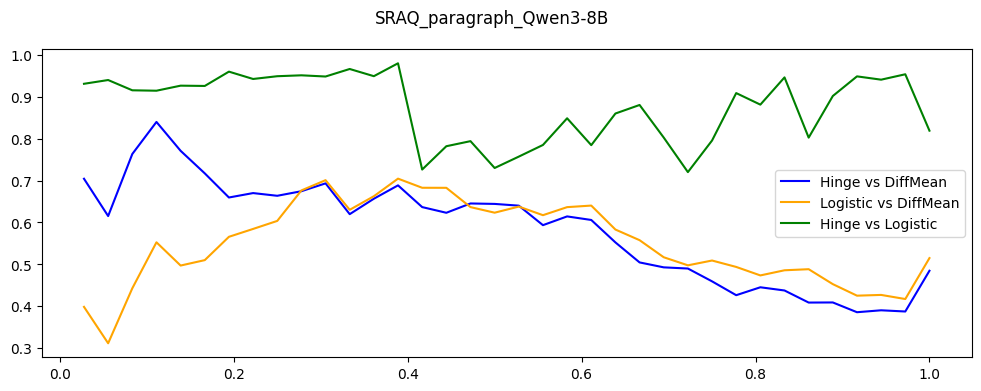

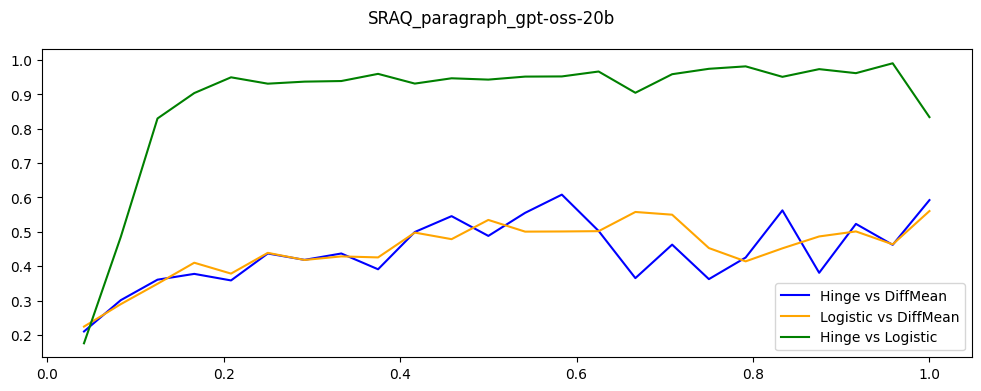

In [1]:
from matplotlib import pyplot as plt
import json
import numpy as np

syn = json.loads(open("within_dataset_cosines_pca_64.json", "r").read())



for key, values in syn.items():
    plt.figure(figsize=(12, 4))
    plt.suptitle(key)
    layers = len(values['cosine_hinge_diffmean'])

    plt.plot(np.arange(1, layers)/(layers-1), values['cosine_hinge_diffmean'][1:], label='Hinge vs DiffMean', color='blue')
    plt.plot(np.arange(1, layers)/(layers-1), values['cosine_logistic_diffmean'][1:], label='Logistic vs DiffMean', color='orange')
    plt.plot(np.arange(1, layers)/(layers-1), values['cosine_hinge_logistic'][1:], label='Hinge vs Logistic', color='green')
    plt.legend()
    plt.show()